# Classical Classification
### An intro to Classification with Scikit-Learn

Classification is a core task in Machine Learning. Thus, we can explore the multiple ways that Scikit-Learn provides for us.

For a more challenging task, we will be using the Digits dataset, which is basically MNIST but 8x8. We take reference to https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html.

In [27]:
# Standard scientific Python imports
import matplotlib.pyplot as plt

# Import datasets, classifiers and performance metrics
import sklearn
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split

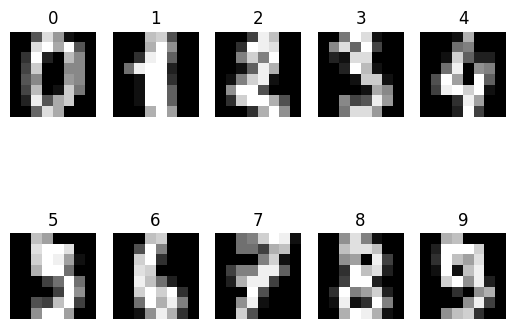

In [17]:
digits = datasets.load_digits()

fig, axes = plt.subplots(2, 5)

for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(digits.target[i])
    ax.axis('off')

plt.show()

Since we're just working with really basic ML techniques (no conv etc.) we must convert it into a 1D structure.

In [19]:
digits.images.shape

(1797, 8, 8)

In [25]:
digits_target = digits.target
digits_data = digits.images.reshape((digits.images.shape[0], -1))
digits_data.shape

(1797, 64)

### KNN Classifier
This is one of the most basic techinques. We can use it as a baseline as well as a template for later reference.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(digits_data, digits_target, test_size=0.5, shuffle=False)

In [29]:
clf = sklearn.neighbors.KNeighborsClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

Scikit-learn provides really easy to use metrics for diagnosing issues too!

In [32]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        88
           1       0.95      0.98      0.96        91
           2       0.98      0.93      0.95        86
           3       0.89      0.90      0.90        91
           4       1.00      0.95      0.97        92
           5       0.96      0.98      0.97        91
           6       0.99      1.00      0.99        91
           7       0.95      1.00      0.97        89
           8       0.95      0.90      0.92        88
           9       0.91      0.92      0.92        92

    accuracy                           0.96       899
   macro avg       0.96      0.96      0.96       899
weighted avg       0.96      0.96      0.96       899



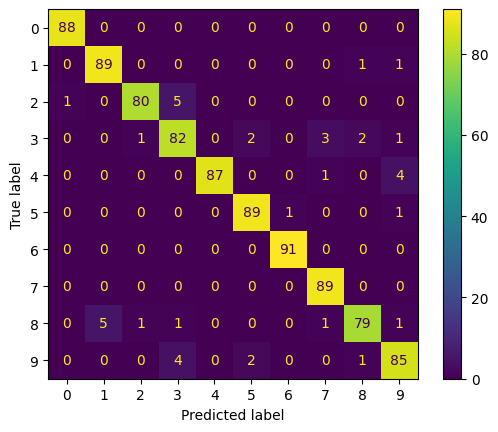

In [34]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### Decision Trees

In [36]:
clf = sklearn.tree.DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

Fun fact: for decision trees, you can also output the probability of each class!

In [45]:
clf.predict_proba(X_test)[0] # In this case its 100% sure though...

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])

In [47]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.90      0.90        88
           1       0.81      0.57      0.67        91
           2       0.85      0.74      0.80        86
           3       0.68      0.78      0.73        91
           4       0.73      0.83      0.78        92
           5       0.60      0.75      0.67        91
           6       0.83      0.86      0.84        91
           7       0.84      0.65      0.73        89
           8       0.61      0.61      0.61        88
           9       0.67      0.73      0.70        92

    accuracy                           0.74       899
   macro avg       0.75      0.74      0.74       899
weighted avg       0.75      0.74      0.74       899



Yikes, not too pretty. Probably because RF doesn't perform well at grasping some concepts.
The upside is that we can easily understand why things work.

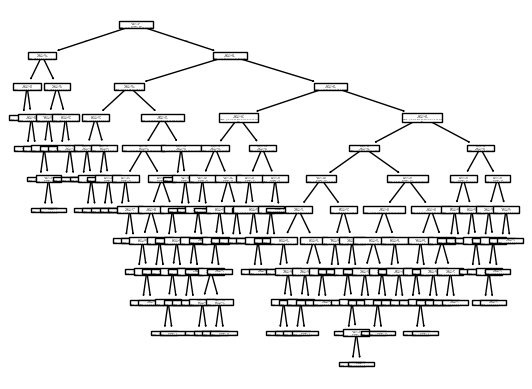

In [50]:
sklearn.tree.plot_tree(clf)
plt.show()

In [52]:
print(sklearn.tree.export_text(clf))

|--- feature_36 <= 0.50
|   |--- feature_42 <= 7.50
|   |   |--- feature_61 <= 5.50
|   |   |   |--- class: 5
|   |   |--- feature_61 >  5.50
|   |   |   |--- feature_25 <= 6.50
|   |   |   |   |--- class: 9
|   |   |   |--- feature_25 >  6.50
|   |   |   |   |--- class: 5
|   |--- feature_42 >  7.50
|   |   |--- feature_37 <= 0.50
|   |   |   |--- feature_26 <= 13.00
|   |   |   |   |--- feature_61 <= 6.50
|   |   |   |   |   |--- class: 8
|   |   |   |   |--- feature_61 >  6.50
|   |   |   |   |   |--- feature_62 <= 5.50
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- feature_62 >  5.50
|   |   |   |   |   |   |--- class: 6
|   |   |   |--- feature_26 >  13.00
|   |   |   |   |--- class: 5
|   |   |--- feature_37 >  0.50
|   |   |   |--- feature_27 <= 12.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_27 >  12.50
|   |   |   |   |--- feature_21 <= 3.50
|   |   |   |   |   |--- class: 4
|   |   |   |   |--- feature_21 >  3.50
|   |   |   |   |   |--- class: 6


I think you can probably see why it doesn't perform too well.

### Random Forest
Maybe it could perform better if we used multiple trees? Welcome to Random Forests.

In [53]:
clf = sklearn.ensemble.RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [54]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        88
           1       0.93      0.90      0.92        91
           2       1.00      0.91      0.95        86
           3       0.91      0.85      0.88        91
           4       0.96      0.92      0.94        92
           5       0.87      0.92      0.89        91
           6       0.98      0.99      0.98        91
           7       0.95      0.98      0.96        89
           8       0.91      0.89      0.90        88
           9       0.84      0.95      0.89        92

    accuracy                           0.93       899
   macro avg       0.93      0.93      0.93       899
weighted avg       0.93      0.93      0.93       899



The documentation also recommends `HistGradientBoostingClassifier` so lets try that...

In [56]:
clf = sklearn.ensemble.HistGradientBoostingClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [57]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        88
           1       0.88      0.84      0.86        91
           2       0.99      0.88      0.93        86
           3       0.87      0.84      0.85        91
           4       0.96      0.89      0.93        92
           5       0.87      0.89      0.88        91
           6       0.96      0.97      0.96        91
           7       0.95      0.97      0.96        89
           8       0.88      0.83      0.85        88
           9       0.78      0.93      0.85        92

    accuracy                           0.90       899
   macro avg       0.91      0.90      0.90       899
weighted avg       0.91      0.90      0.90       899



A lot faster, but also a lot less accurate.

### More Gradient Boosting Techniques (Adaboost, XGBoost, Catboost)

In [59]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [70]:
clf = XGBClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [71]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        88
           1       0.85      0.81      0.83        91
           2       0.94      0.90      0.92        86
           3       0.89      0.82      0.86        91
           4       0.95      0.85      0.90        92
           5       0.88      0.92      0.90        91
           6       0.91      0.91      0.91        91
           7       0.94      0.94      0.94        89
           8       0.86      0.85      0.86        88
           9       0.79      0.92      0.85        92

    accuracy                           0.89       899
   macro avg       0.89      0.89      0.89       899
weighted avg       0.89      0.89      0.89       899



In [72]:
clf = CatBoostClassifier(verbose=False)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [73]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        88
           1       0.93      0.89      0.91        91
           2       0.99      0.91      0.95        86
           3       0.89      0.86      0.87        91
           4       0.98      0.91      0.94        92
           5       0.92      0.95      0.93        91
           6       0.97      1.00      0.98        91
           7       0.94      0.99      0.96        89
           8       0.93      0.88      0.90        88
           9       0.84      0.97      0.90        92

    accuracy                           0.93       899
   macro avg       0.94      0.93      0.93       899
weighted avg       0.94      0.93      0.93       899



Wow, nothing even comes close to beating KNN.

### SVM

In [76]:
clf = sklearn.svm.SVC()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [77]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        88
           1       0.97      0.97      0.97        91
           2       1.00      0.98      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.93      0.97      0.95        91
           6       0.99      0.99      0.99        91
           7       0.95      0.99      0.97        89
           8       0.92      0.95      0.94        88
           9       0.92      0.96      0.94        92

    accuracy                           0.96       899
   macro avg       0.96      0.96      0.96       899
weighted avg       0.96      0.96      0.96       899



Nevermind! SVM is similar good at KNN, probably because (according to ChatGPT) the data is quite clean and the the data looks very similar in feature space.

### Logistic Regression
I forgot this because I thought it was regression... rookie mistake

In [90]:
clf = sklearn.linear_model.LogisticRegression(max_iter=100000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [91]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97        88
           1       0.93      0.90      0.92        91
           2       0.99      0.98      0.98        86
           3       0.94      0.84      0.88        91
           4       0.98      0.91      0.94        92
           5       0.88      0.93      0.90        91
           6       0.91      0.99      0.95        91
           7       0.98      0.96      0.97        89
           8       0.89      0.90      0.89        88
           9       0.84      0.93      0.89        92

    accuracy                           0.93       899
   macro avg       0.93      0.93      0.93       899
weighted avg       0.93      0.93      0.93       899

